# 25 DMOs -> fatigue

In [1]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.model import DMOLSTM, ModelConfig
from src.core.enums import MileStone, PatientDataType, DataFrequency
from src.model import lstm_regression
from src.train import TrainRegression
from src.pipeline.dmo.dmo_into_dataloader import dmo_into_dataloader

import matplotlib.pyplot as plt

import numpy as np
import torch

In [2]:
from torch.nn import HuberLoss, CrossEntropyLoss, MSELoss
from torch.optim import Adam

config = ModelConfig(
    name="lstm_regression",
    model_type="LSTM",
    input_size=25,
    hidden_size=128,
    num_layers=1,
    output_size=1,
    batch_size=16,
    epochs=50,
    optimiser=Adam,
    loss_fn=MSELoss(),
    learning_rate=5e-4,
)

config.notes = "None"

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
    "total_worn_h",
]

In [5]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [6]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [7]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, days, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [8]:
dmo_data = dmo_data.mean(axis=2)

In [9]:
dmo_data = dmo_data.flatten(start_dim=0, end_dim=1)
dmo_data = dmo_data.unsqueeze(1)
dmo_labels = dmo_labels.flatten(start_dim=0, end_dim=1)
dmo_labels = dmo_labels.unsqueeze(dim=1)
print(dmo_data.shape)
print(dmo_labels.shape)

torch.Size([1400, 1, 25])
torch.Size([1400, 1, 1])


In [10]:
transforms = (None, None)
training_dl, testing_dl = dmo_into_dataloader(dmo_data, dmo_labels, batch_size=16, transforms=transforms)

In [11]:
model = DMOLSTM(config).to(device=device)
optimiser = config.optimiser(model.parameters(), lr=config.learning_rate)

trainer = TrainRegression(
    model,
    optimiser,
    config,
    training_dl,
    testing_dl,
    #training_dl,
    device,
    verbose=True,
)

trainer.train_loop()
prediction, actual = trainer.test_loop()


Testing loss: 0.06917661821676625


In [12]:
print(prediction)
print(actual)

[tensor([[0.6115]]), tensor([[0.3722]]), tensor([[0.1361]]), tensor([[0.5912]]), tensor([[0.2056]]), tensor([[0.4962]]), tensor([[0.2624]]), tensor([[0.2279]]), tensor([[0.4320]]), tensor([[0.3500]]), tensor([[0.5798]]), tensor([[0.4310]]), tensor([[0.6052]]), tensor([[0.4988]]), tensor([[0.5159]]), tensor([[0.3780]]), tensor([[0.5925]]), tensor([[0.5881]]), tensor([[0.5217]]), tensor([[0.6265]]), tensor([[0.5136]]), tensor([[0.5501]]), tensor([[0.5606]]), tensor([[0.4536]]), tensor([[0.5932]]), tensor([[0.1651]]), tensor([[0.6887]]), tensor([[0.4041]]), tensor([[0.5429]]), tensor([[0.5223]]), tensor([[0.3265]]), tensor([[0.4742]]), tensor([[0.3464]]), tensor([[0.4868]]), tensor([[0.3701]]), tensor([[0.4994]]), tensor([[0.5579]]), tensor([[0.5466]]), tensor([[0.5427]]), tensor([[0.5124]]), tensor([[0.2839]]), tensor([[0.5904]]), tensor([[0.5548]]), tensor([[0.4287]]), tensor([[0.5578]]), tensor([[0.5082]]), tensor([[0.5340]]), tensor([[0.7221]]), tensor([[0.5640]]), tensor([[0.3874]]),

All metrics: {'accuracy': 0.31785714285714284, 'Mean Squared Error': 0.07040423154830933, 'Mean Absolute Error': 0.2118629515171051, 'R^2': -0.2566182613372803}


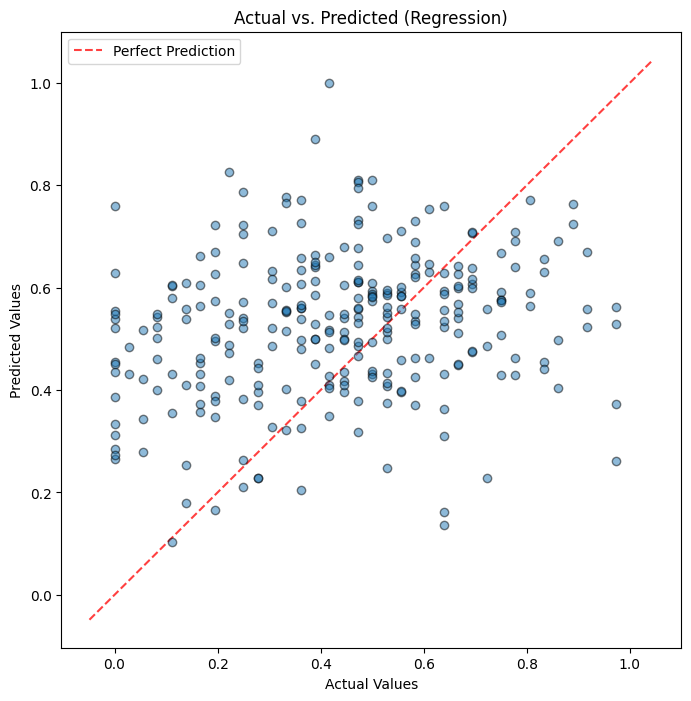

In [13]:
from src.evaluation import Evaluation

actual_values = torch.Tensor(actual)
predicted_values = torch.Tensor(prediction)

evaluation = Evaluation(predicted_values, actual_values)
print(f"All metrics: {evaluation.compute_all_metrics()}")
evaluation.evaluation_plot().show()


In [ ]:
# convert training and testing dataloader back to tensor
all_inputs_training = []

for a, b in training_dl:
    patient, visit, features = a.shape
    for p in range(patient):
        all_inputs_training.append(a[p])

training_tensor = torch.stack(all_inputs_training)

all_inputs_testing = []

for a, b in testing_dl:
    patient, visit, features = a.shape
    for p in range(patient):
        all_inputs_testing.append(a[p])

testing_tensor = torch.stack(all_inputs_testing)

torch.Size([1, 25])


In [40]:
print(training_tensor.shape)

torch.Size([1120, 1, 25])


In [71]:
# Have to wrap the model to format the output so shap can use it (bit silly tho)

from torch import nn

class LSTMWrapper(nn.Module):
    def __init__(self, model, device):
        super().__init__()
        self.model = model
        self.device = device

    def forward(self, input_data):
        data = input_data.to(device=self.device, dtype=torch.float32)
        output = self.model(data)
        
        if isinstance(output, tuple):
            output = output[0]

        output = output.squeeze(-1)

        return output

In [83]:
import shap
torch.backends.cudnn.enabled = False

device = torch.device("cpu")
model = model.to(device=device)
model_wrapper = LSTMWrapper(model, device)
model_wrapper.eval()


background_data = training_tensor[:].to(device=device)
data = testing_tensor[:].to(device=device)

explainer = shap.GradientExplainer(model_wrapper, background_data)
shap_values = explainer.shap_values(data)

In [84]:
shap_values = shap_values.squeeze()
shap_values.shape

(280, 25)

/tmp/ipykernel_11000/2007217077.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, data.squeeze().cpu().numpy(), feature_names=dmo_features)


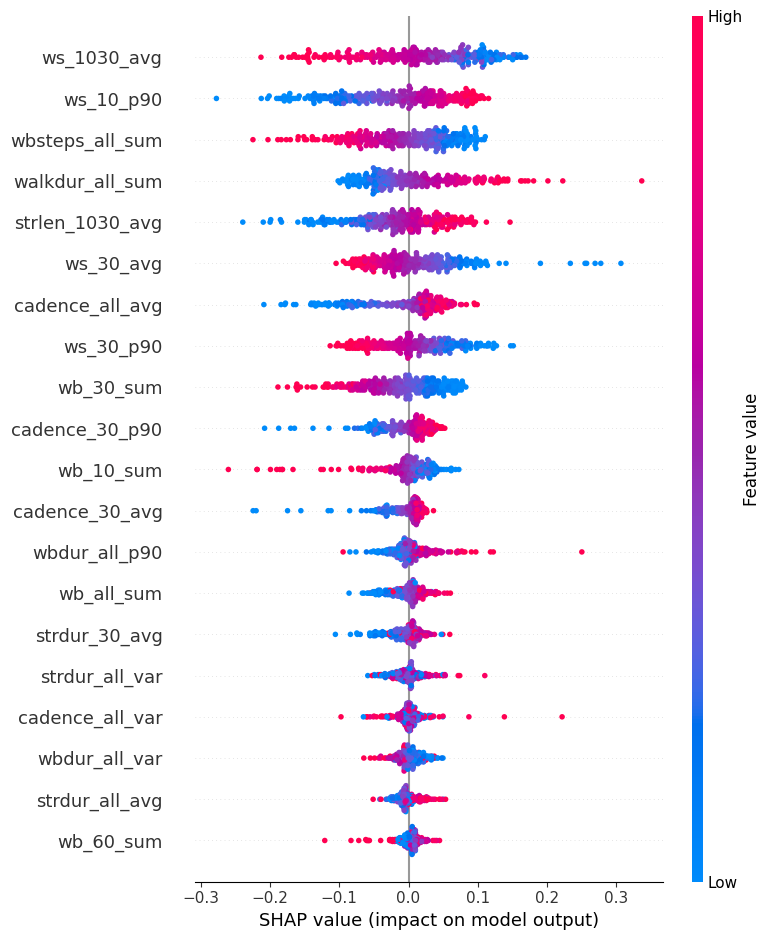

In [85]:
shap.summary_plot(shap_values, data.squeeze().cpu().numpy(), feature_names=dmo_features)